# BayesFlow: Personwise Model Comparison (Mammals)

Author:      David Izydorczyk 

Reminder: Install new packages with `python3.11 -m pip install package`  | active environemnt `.\personwise_BF\Scripts\activate`

In [1]:
import numpy as np
import numpy.random as rng


import matplotlib.pyplot as plt
import seaborn as sns


import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "jax"

import keras
import bayesflow as bf
import pandas as pd
import statsmodels.formula.api as sm



from plotnine import (
    theme_set,
    theme_bw
)
theme_set(theme_bw())


INFO:bayesflow:Using backend 'jax'


In [2]:
import utils.helper_functions as fn
import utils.model_functions as mf

# makes sure mf is loaded correctly
import importlib
importlib.reload(mf) 
importlib.reload(fn) 

<module 'utils.helper_functions' from 'c:\\Users\\dizydorc\\OneDrive\\University\\Project Github Repositories\\Estimation processes in real-world domains\\Scripts\\Sensitivity Model Comparison\\utils\\helper_functions.py'>

In [3]:
# avoid scientific notation for outputs
np.set_printoptions(suppress=True)

# 1 Load Design Data 

In [4]:
df = pd.read_csv('..\..\Materials\design_data_mammals.csv', sep=';',decimal=",")
df.head()

,ID,item,crit,img,training,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10
0,1,Aoudad,335,01.png,0,-0.567875,-0.015278,0.216645,-0.260836,-0.047524,-0.193240,0.043678,-0.002896,-0.120112,0.076603
1,2,Brazilian tapir,1095,02.png,0,-0.392465,0.184646,-0.071257,-0.027939,0.298438,-0.240948,-0.174659,-0.244244,0.003726,-0.023815
2,3,American bison,912,03.png,0,-0.553953,-0.067230,0.094129,-0.232337,0.206952,0.030337,0.129310,0.098340,-0.205172,0.202011
3,4,Giant anteater,1186,04.png,0,0.067508,0.169333,-0.082213,0.037893,0.284212,-0.473084,-0.060646,-0.019342,0.346182,-0.129704
4,5,Ibex,797,05.png,0,-0.557179,0.020041,0.214498,-0.259488,-0.106287,-0.071999,-0.062104,-0.004846,-0.196821,0.151096


In [5]:
all_cues = df[[f'dim_{i}' for i in range(1, 11)]].to_numpy(dtype=float)
all_crit = df[['crit']].to_numpy(dtype=float).flatten()

# Get Exemplar Set 
exemplars = df.loc[df['training'] == 1,:] 
ex_cues   = exemplars[[f'dim_{i}' for i in range(1, 11)]].to_numpy(dtype=float)
ex_crit   = exemplars[['crit']].to_numpy(dtype=float).flatten()
ex_IDs    = exemplars[["ID"]].to_numpy(dtype=float).squeeze().astype(int)

# Get Data from only Testing items
testing = df.loc[df['training'] == 0,:]

# Get the IDs
test_IDs = testing[["ID"]].to_numpy(dtype=float).squeeze().astype(int)

# Extract cues of the testing stimuli
cues     = testing[[f'dim_{i}' for i in range(1, 11)]].to_numpy(dtype=float)

# Make cue dictionary
dict_cues = {f"cue_{i}": cues[:, i] for i in range(cues.shape[1])}

# Geet number of trials and number of dimensions
n_trials, n_dim     = cues.shape

print("n_trials:", n_trials)
print("n_dim:"   , n_dim)

n_trials: 68
n_dim: 10


In [6]:
# Set general parameters
rate = 0.01

In [7]:
# Define positional encodings
position_encodings = np.linspace(0, 1, n_trials, dtype=np.float32)

# 2 Define Models

## 2.1 CAM - Cue Abstraction (Rule) Model 

In [8]:
# Run Regression on whole item samples
result = sm.ols(formula="crit ~ dim_1 + dim_2 + dim_3 + dim_4 + dim_5 + dim_6 + dim_7 + dim_8 + dim_9 + dim_10", data=df).fit()
# print(result.params)
# print(result.summary())

In [9]:
def prior_CAM(n_dim = n_dim, rate = rate):

    # Init weight parameters
    w = np.zeros(n_dim+1)

    # Intercept
    w[0]   = rng.normal(984.65, 300)

    # Dimension weights (Importance)
    w[1:]  = rng.normal(0, 750, size = n_dim)

    sigma  = rng.exponential(1/rate)

    return dict(w=w, sigma=sigma)

In [10]:
def model_CAM(w, sigma, cues=cues, p=position_encodings):

    n_trials, _   = cues.shape
  
    # Pre-allocate the output matrix
    pred_crit = mf.CAM_experiment(w,cues)

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=10000, size=n_trials)
    
    return dict(x=x, p=p)  


In [11]:
simulator_CAM = bf.make_simulator([prior_CAM, model_CAM])

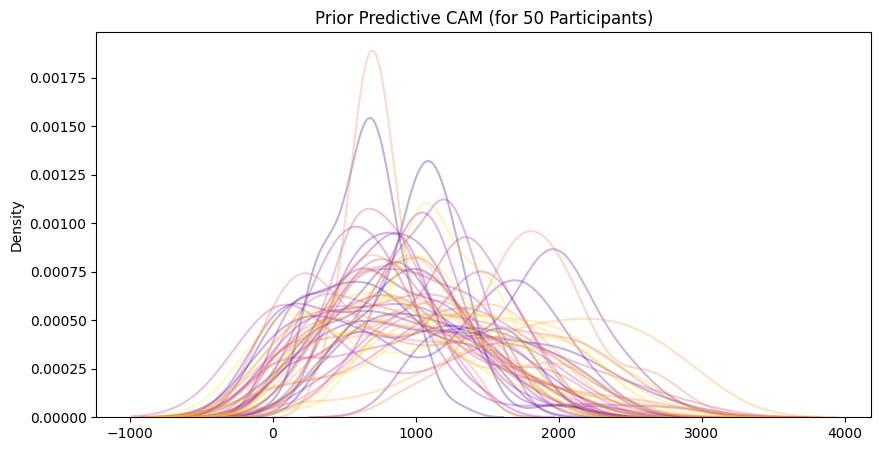

In [12]:
fig, ax = fn.plot_prior_predictives(simulator_CAM, "CAM")

## 2.2 GCM - Exemplar Model


In [13]:
def prior_GCM(n_dim = n_dim, rate = rate):

    c      = rng.exponential(1/0.1)
    w      = rng.dirichlet(np.ones(n_dim), size = 1)*n_dim
    sigma  = rng.exponential(1/rate)

    return dict(c=c, w=w.squeeze(), sigma=sigma)

In [14]:
def model_GCM(c, w, sigma, cues=cues, ex_cues=ex_cues, ex_crit=ex_crit, p=position_encodings):
  
    n_trials = cues.shape[0]

    # Make predictions based on the GCM model for all trials at once
    pred_crit = mf.GCM_experiment(cues, ex_cues, ex_crit, w, c)

    # Simulate responses
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=10000, size=n_trials)

    return dict(x=x, p=p)

In [15]:
simulator_GCM = bf.make_simulator([prior_GCM, model_GCM])

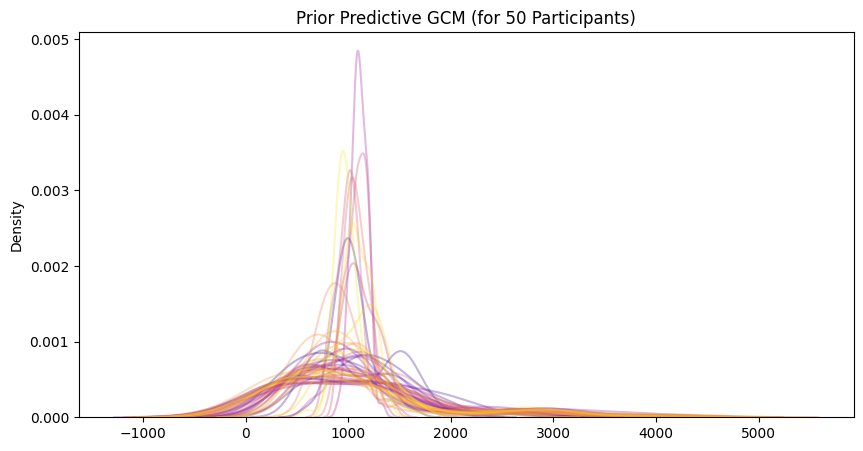

In [16]:
fig, ax = fn.plot_prior_predictives(simulator_GCM, "GCM")

## 2.3 RulExJ Model


In [17]:
def prior_RULEXJ(n_dim = n_dim, rate = rate):

    # Rule part
    CAM_pars = prior_CAM(n_dim = n_dim, rate = rate)

    # Exemplar part
    GCM_pars = prior_GCM(n_dim = n_dim, rate = rate)

    # Blending
    a        = rng.uniform(0,1)

    return dict(alpha = a, w_CAM=CAM_pars["w"], c = GCM_pars["c"], w_GCM = GCM_pars["w"], sigma=CAM_pars["sigma"])

In [18]:
def model_RULEXJ(alpha, w_CAM, c, w_GCM, sigma,  cues=cues, ex_cues=ex_cues, ex_crit=ex_crit, p=position_encodings):
    
    n_trials, _   = cues.shape
    
    pred_CAM = mf.CAM_experiment(w_CAM,cues)

    pred_GCM = mf.GCM_experiment(cues, ex_cues, ex_crit,w_GCM,c)

    pred_RULEXJ = alpha*pred_CAM + (1-alpha)*pred_GCM

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_RULEXJ, sd=sigma, low=0, upp=10000, size=n_trials)

    return dict(x=x, p=p)

In [19]:
simulator_RULEXJ = bf.make_simulator([prior_RULEXJ, model_RULEXJ])

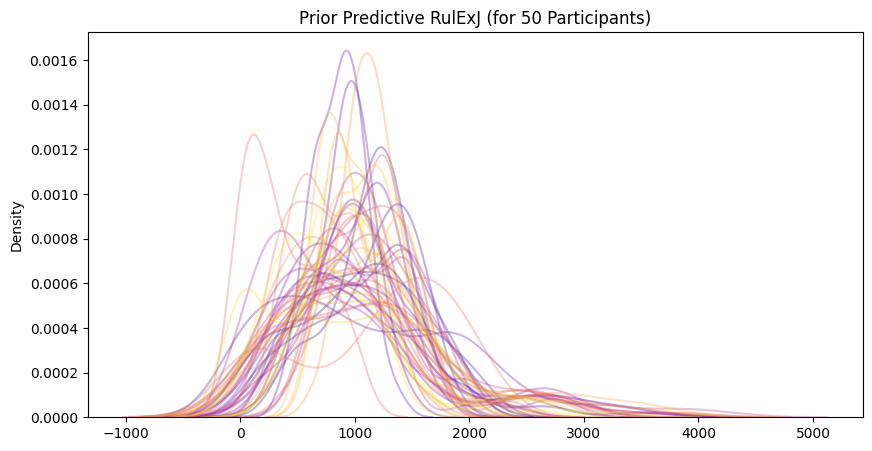

In [20]:
fig, ax = fn.plot_prior_predictives(simulator_RULEXJ, "RulExJ")

## 2.4 Mapping Model (MAPP)

For the mapping model, the direction of the cues have to coded so that each cue (i.e., dimension) has a positive relationship with the criterion.

In [21]:
# Change cue direction and redefine exemplar and stimuli cues for the mapping model
all_mapp_cues  = mf.preprocess_cues(all_cues,all_crit)
ex_mapp_cues   = all_mapp_cues[ex_IDs-1,:]
mapp_cues      = all_mapp_cues[test_IDs-1,:]
dict_mapp_cues = {f"cue_{i}": mapp_cues[:, i] for i in range(mapp_cues.shape[1])}

In [22]:
def prior_MAPP(lower = 2, upper = 12, rate = rate):

    n_cats = fn.truncated_poisson_np(5, lower = lower, upper = upper)
    sigma  = rng.exponential(1/rate)
    
    return  dict(n_cats=n_cats[0], sigma=sigma)

In [23]:
def model_MAPP(n_cats, sigma, cues=mapp_cues,ex_cues=ex_mapp_cues, ex_crit=ex_crit, p=position_encodings):

    n_trials, _   =  cues.shape 

    # Make predictions based on the GCM model for each person
    pred_crit = mf.MAPP_experiment(n_cats,cues,ex_cues,ex_crit)

    # Simulate responses 
    x = fn.truncnorm_r(mean=pred_crit, sd=sigma, low=0, upp=10000, size=n_trials)
  

    return dict(x=x, p=p)

In [24]:
simulator_MAPP = bf.make_simulator([prior_MAPP, model_MAPP])

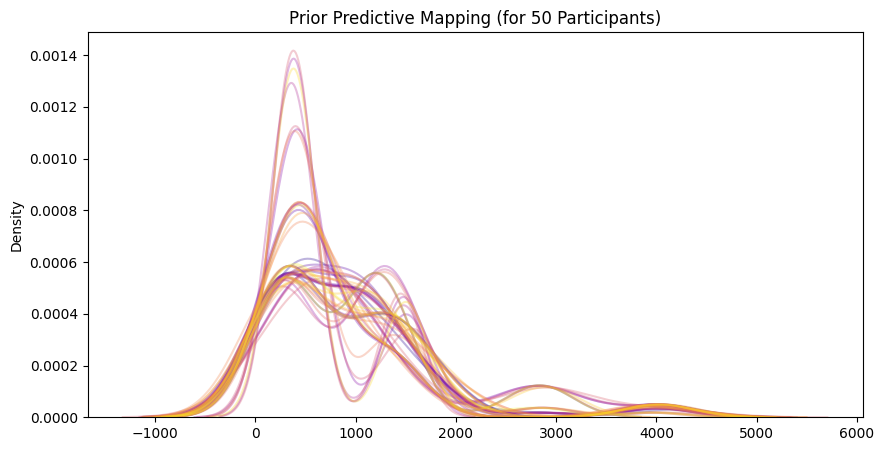

In [25]:
fig, ax = fn.plot_prior_predictives(simulator_MAPP, "Mapping")

## 2.5 QuickEst

For the QuickEst-Model, the direction of the cues have to coded so that each cue (i.e., dimension) has a positive relationship with the criterion. Also the cues need to binary.

In [26]:
# Change cue direction and redefine exemplar and stimuli cues for the QuickEst model
all_QEst_cues  = mf.preprocess_cues_QuickEst(all_cues,all_crit)
ex_QEst_cues   = all_QEst_cues[ex_IDs-1,:]
QEst_cues      = all_QEst_cues[test_IDs-1,:]
dict_QEst_cues = {f"cue_{i}": QEst_cues[:, i] for i in range(QEst_cues.shape[1])}

In [27]:
def prior_QEst():

    sigma = fn.truncated_cauchy_np(loc=0, scale=100, lower=0.001, upper=1000, size=1)

    return dict(sigma=sigma)

In [28]:
def model_QEst(sigma,  cues = QEst_cues, ex_cues = ex_QEst_cues, ex_crit = ex_crit, p=position_encodings):
 
    # Step 0: Draw "memorized" ex_crit for each participant
    mem_ex_crit = np.random.normal(ex_crit,sigma) 

    # Make predictions based on the GCM model for each person
    x = mf.QuickEst_experiment(cues,ex_cues,mem_ex_crit)
 

    return dict(x = np.clip(x, 0, 10000), p=p)

In [29]:
simulator_QEst = bf.make_simulator([prior_QEst, model_QEst])

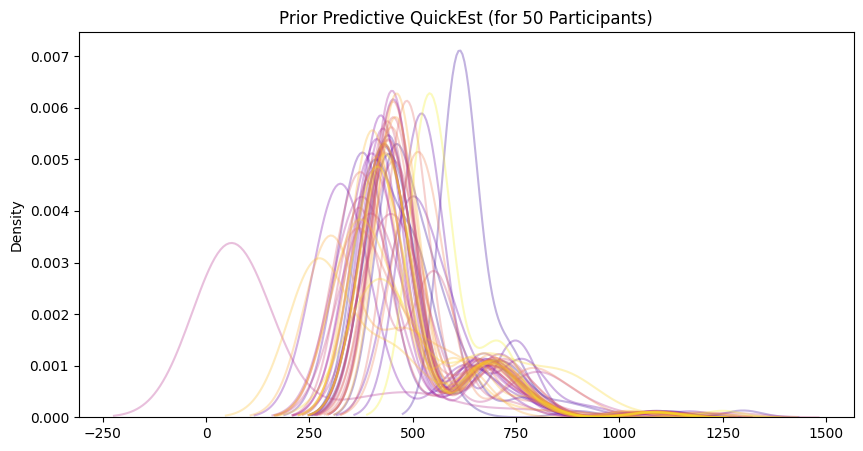

In [30]:
fig, ax = fn.plot_prior_predictives(simulator_QEst, "QuickEst")

## 2.6 RGuess - Random Guessing 

In [31]:
def prior_RGuess():

    sigma_range = rng.exponential(1/0.01, size = 1)

    return  dict(sigma_range=sigma_range)

In [32]:
def model_RGuess(sigma_range, cues = cues, ex_crit = ex_crit, p=position_encodings):

    n_trials, _   =  cues.shape 

    min_observed_crit = rng.normal(np.min(ex_crit),sigma_range)
    range_width = max(0.01, rng.normal(np.max(ex_crit) - np.min(ex_crit), sigma_range))  # enforce positive width

    max_observed_crit = min_observed_crit + abs(range_width)

    x =  rng.uniform(min_observed_crit, max_observed_crit, size = n_trials)
    
    return dict(x = np.clip(x, 0, 10000), p=p)


In [33]:
simulator_RGuess = bf.make_simulator([prior_RGuess, model_RGuess])

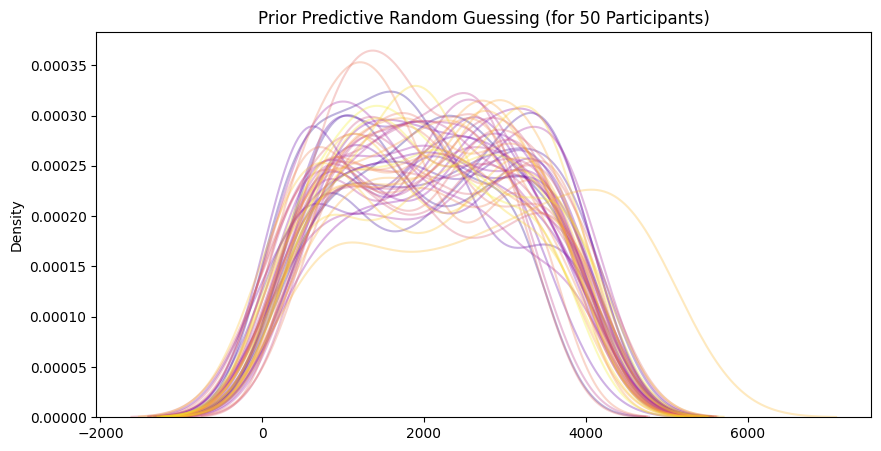

In [34]:
fig, ax = fn.plot_prior_predictives(simulator_RGuess, "Random Guessing")

# 3 Training Networks & Fit data

In [53]:
# Load data
df   = pd.read_csv('..\..\Data\data_analysis_mammals.csv', sep = ",")
data = df.to_numpy()
data = np.float32(data[(test_IDs-1),5:])
n_trials, n_sub = data.shape

n_models = 6    

In [54]:
simulator = bf.simulators.ModelComparisonSimulator(
    simulators        = [simulator_RULEXJ,simulator_CAM,simulator_GCM,simulator_MAPP,simulator_QEst,simulator_RGuess],
    use_mixed_batches = True
)

In [55]:
num_batches_per_epoch = 2
batch_size            = 64
epochs                = 2

n_networks            = 10

In [56]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")   
    .as_time_series(["x","p"])
    .standardize("x")
    .drop(["alpha","c","sigma","w_GCM","w_CAM","n_cats","sigma_range"])
    .concatenate(["x", "p"], into="summary_variables")
)

summary_network    = bf.networks.TimeSeriesNetwork(summary_dim=20)

classifier_network = bf.networks.MLP(widths=[256] * 32, activation="silu", dropout=None)

learning_rate = keras.optimizers.schedules.CosineDecay(1e-4, decay_steps=epochs * num_batches_per_epoch)
optimizer     = keras.optimizers.Adam(learning_rate=learning_rate)


In [ ]:
for network in range(n_networks):

    print(f'Starting to train network {network} using ...')
    approximator = bf.approximators.ModelComparisonApproximator(
        num_models         = 6,
        classifier_network = classifier_network,
        summary_network    = summary_network,
        adapter            = adapter,
    )

    approximator.compile(optimizer=optimizer)

    history = approximator.fit(epochs = epochs, batch_size = batch_size,  num_batches = num_batches_per_epoch, adapter = adapter, simulator = simulator)

    # Save model
    approximator.save("..\..\Results\Sensitivity Model Comparison\Trained Networks\sensitivity_MC_MAMMALS_" + str(network) + ".keras")
    print(f'Finished training network {network}')

    all_pmps = np.zeros((n_sub, n_models)) 

    for i in range(n_sub):
        pmp         = approximator.predict(conditions=dict(x=data[:,i], p = position_encodings))[0]
        all_pmps[i] = pmp.flatten() 

    # Store results
    all_pmps_df  = pd.DataFrame(all_pmps)
    all_pmps_df.columns = ["RULEXJ", "CAM", "GCM", "MAPP", "QEst", "RGuess"]


    all_pmps_df.to_csv("..\..\Results\Sensitivity Model Comparison\pmp_MAMMALS_" + str(network) + ".csv")

    print(f'Finished fitting network {network} to participants')

INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.
INFO:bayesflow:Incompatible simulator output. The following keys will be dropped: alpha, c, n_cats, sigma, sigma_range, w, w_CAM, w_GCM.


Starting to train network 0 using ...
Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - loss: 1189.5099 - loss/classifier_loss: 1189.5099
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 440.0836 - loss/classifier_loss: 440.0836
Finished training network 0


INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.


Finished fitting network 0 to participants
Starting to train network 1 using ...
Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - loss: 3629.9504 - loss/classifier_loss: 3629.9504
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - loss: 3834.3030 - loss/classifier_loss: 3834.3030
Finished training network 1


INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.


...

Finished fitting network 6 to participants
Starting to train network 7 using ...
Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - loss: 1793.8970 - loss/classifier_loss: 1793.8970
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 1717.2938 - loss/classifier_loss: 1717.2938
Finished training network 7


INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.


Finished fitting network 7 to participants
Starting to train network 8 using ...
Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - loss: 1566.5471 - loss/classifier_loss: 1566.5471
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 1810.7690 - loss/classifier_loss: 1810.7690
Finished training network 8


INFO:bayesflow:Building dataset from simulator instance of ModelComparisonSimulator.
INFO:bayesflow:Using 16 data loading workers.
INFO:bayesflow:Building on a test batch.


Finished fitting network 8 to participants
Starting to train network 9 using ...
Epoch 1/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - loss: 2145.9131 - loss/classifier_loss: 2145.9131
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 2326.7727 - loss/classifier_loss: 2326.7727
Finished training network 9
Finished fitting network 9 to participants
